## Heikin Ashi indicator
Unlike regular candlesticks (which show raw open-high-low-close data for each period), Heikin Ashi candlesticks apply a smoothing formula to make price trends easier to spot.

## Outline
1. Imports and Notebook Configuration
2. Historical Price Data Acquisition
3. Heikin-Ashi Candle Construction
4. Trend & Signal Logic (Bull/Bear Detection)
5. Vectorized Backtest Engine (Entries/Exits)
6. Performance & Risk Metrics Computation
7. Stop-Loss / Take-Profit & Position Sizing
8. Parameter Grid / Random Search Optimization
9. Walk-Forward (Out-of-Sample) Evaluation
10. Visualization: Standard vs Heikin-Ashi with Signals

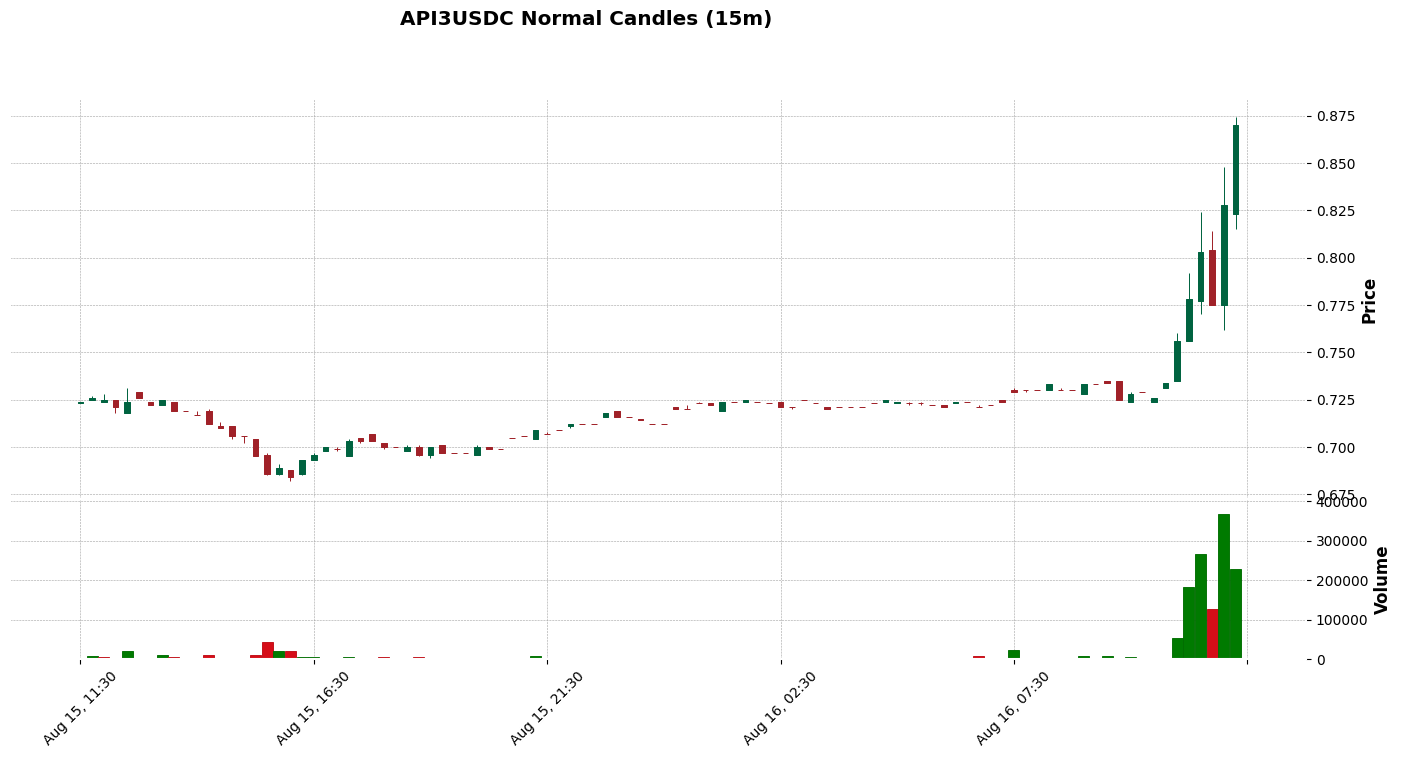

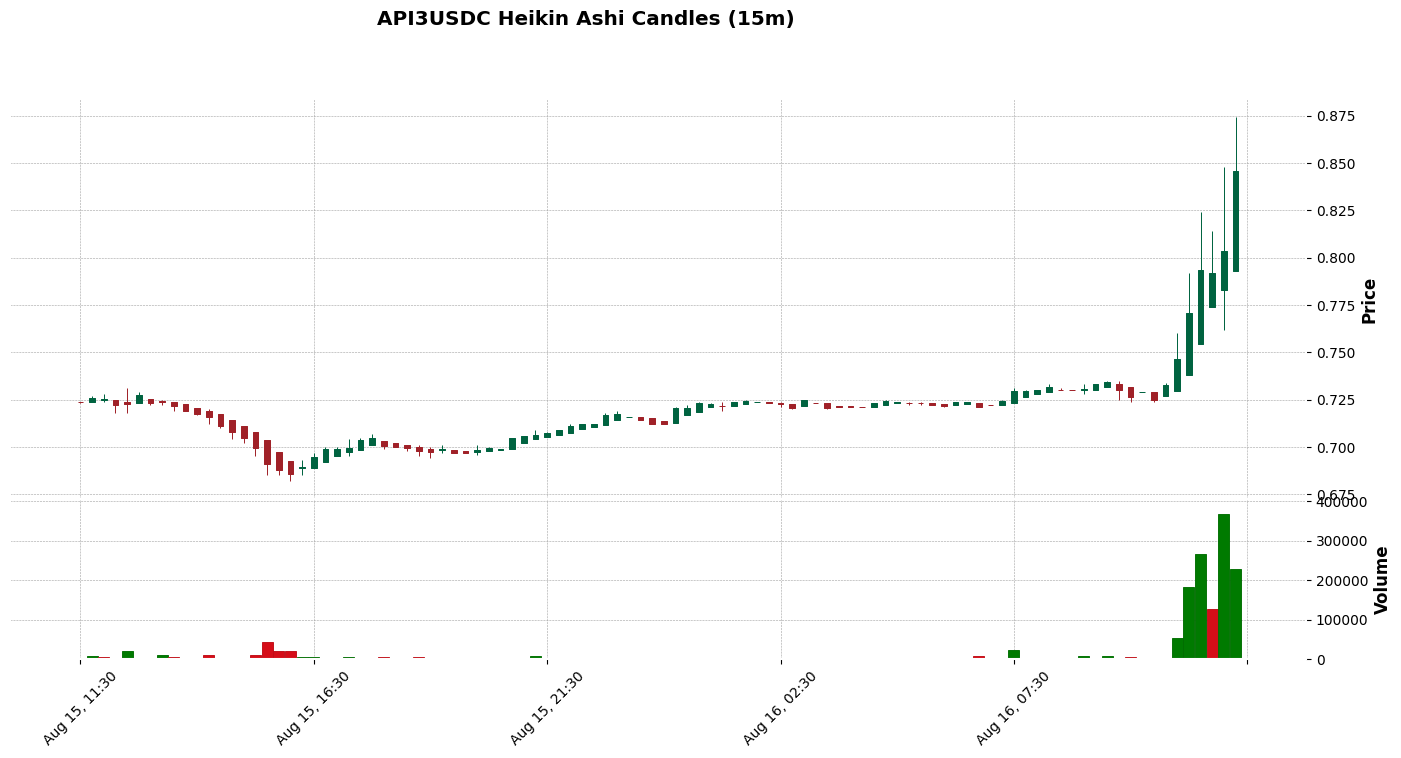

In [15]:
import requests
import pandas as pd
import mplfinance as mpf

# Binance API endpoint for klines (EPICUSDC, 15m)
symbol = "API3USDC"   # change to BTCUSDT if EPIC not listed
interval = "15m"
limit = 100

url = f"https://api.binance.com/api/v3/klines?symbol={symbol}&interval={interval}&limit={limit}"
response = requests.get(url)
data = response.json()

# Convert to DataFrame
cols = ["timestamp", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "trades",
        "taker_base_vol", "taker_quote_vol", "ignore"]
df = pd.DataFrame(data, columns=cols)

# Convert numeric columns
for col in ["open", "high", "low", "close", "volume"]:
    df[col] = df[col].astype(float)

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
df.set_index("timestamp", inplace=True)

# -------- Heikin Ashi calculation --------
ha_df = pd.DataFrame(index=df.index, columns=["open", "high", "low", "close"])
ha_df["close"] = (df["open"] + df["high"] + df["low"] + df["close"]) / 4

ha_open = [(df["open"].iloc[0] + df["close"].iloc[0]) / 2]
for i in range(1, len(df)):
    ha_open.append((ha_open[i-1] + ha_df["close"].iloc[i-1]) / 2)
ha_df["open"] = ha_open

ha_df["high"] = df[["high"]].join(ha_df[["open", "close"]]).max(axis=1)
ha_df["low"] = df[["low"]].join(ha_df[["open", "close"]]).min(axis=1)

# Prepare both for mplfinance
df_mpf = df[["open", "high", "low", "close", "volume"]]
ha_mpf = ha_df[["open", "high", "low", "close"]].copy()
ha_mpf["volume"] = df["volume"]

# Plot
mpf.plot(df_mpf, type="candle", style="charles",
         title=f"{symbol} Normal Candles (15m)",
         volume=True, figsize=(18,8))

mpf.plot(ha_mpf, type="candle", style="charles",
         title=f"{symbol} Heikin Ashi Candles (15m)",
         volume=True, figsize=(18,8))

## Heikin Ashi Strategy Variants
Three common Heikin Ashi-based strategies: MA filter, wickless candle, and RSI confirmation.

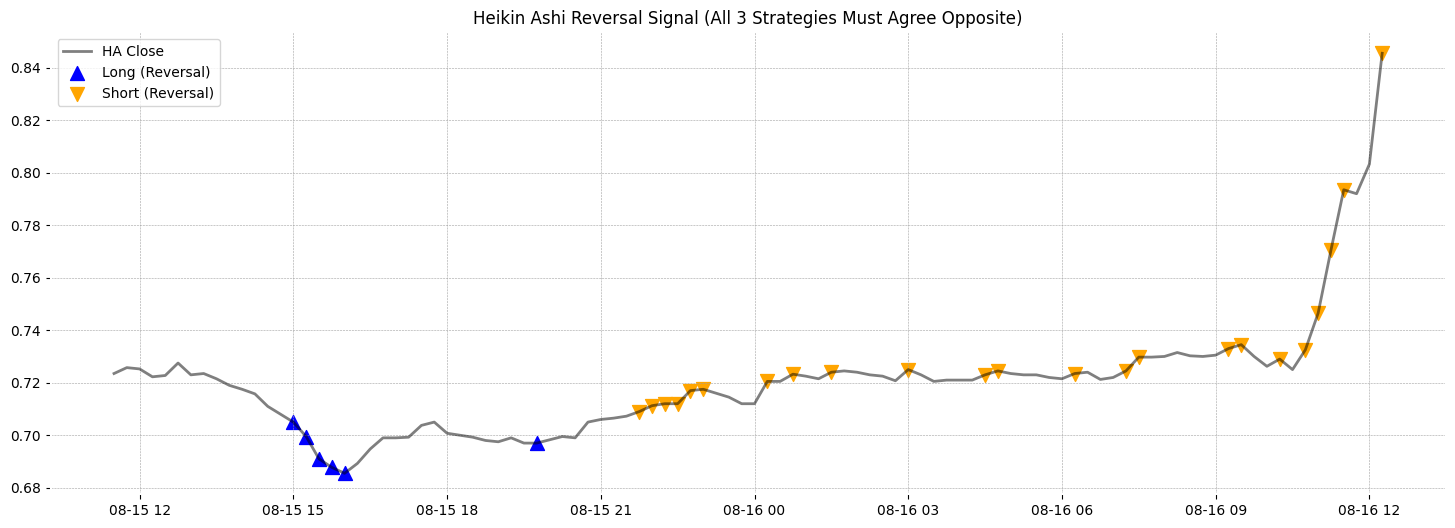

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ HA + Moving Average Filter
def ha_ma_signal(df, ma_period=50, ma_type='ema'):
    if ma_type == 'ema':
        ma = df['close'].ewm(span=ma_period, adjust=False).mean()
    else:
        ma = df['close'].rolling(ma_period).mean()
    ha_up = df['close'] > df['open']
    ha_dn = df['close'] < df['open']
    long = (ha_up) & (df['close'] > ma)
    short = (ha_dn) & (df['close'] < ma)
    signal = np.where(long, 1, np.where(short, -1, 0))
    return signal

# 2️⃣ HA Wickless Candle Rule
def ha_wickless_signal(df):
    bullish = (df['close'] > df['open']) & (df['low'] == df['open'])
    bearish = (df['close'] < df['open']) & (df['high'] == df['open'])
    signal = np.where(bullish, 1, np.where(bearish, -1, 0))
    return signal

# 3️⃣ HA + RSI Confirmation
def ha_rsi_signal(df, rsi_period=14):
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(rsi_period).mean()
    rs = gain / (loss + 1e-9)
    rsi = 100 - (100 / (1 + rs))
    ha_up = df['close'] > df['open']
    ha_dn = df['close'] < df['open']
    rsi_up = rsi > rsi.shift(1)
    rsi_dn = rsi < rsi.shift(1)
    long = ha_up & rsi_up
    short = ha_dn & rsi_dn
    signal = np.where(long, 1, np.where(short, -1, 0))
    return signal

# Ensure signals are present before using them
ha_df['HA_MA_Signal'] = ha_ma_signal(ha_df)
ha_df['HA_Wickless_Signal'] = ha_wickless_signal(ha_df)
ha_df['HA_RSI_Signal'] = ha_rsi_signal(ha_df)

# Reversal: emit long when all three agree on short, and short when all three agree on long
ha_df['HA_Reversal_Signal'] = 0
long_mask_rev = (ha_df['HA_MA_Signal'] == -1) & (ha_df['HA_Wickless_Signal'] == -1) & (ha_df['HA_RSI_Signal'] == -1)
short_mask_rev = (ha_df['HA_MA_Signal'] == 1) & (ha_df['HA_Wickless_Signal'] == 1) & (ha_df['HA_RSI_Signal'] == 1)
ha_df.loc[long_mask_rev, 'HA_Reversal_Signal'] = 1
ha_df.loc[short_mask_rev, 'HA_Reversal_Signal'] = -1

# Plot the reversal signal
plt.figure(figsize=(18,6))
plt.plot(ha_df.index, ha_df['close'], label='HA Close', color='black', alpha=0.5)
plt.scatter(ha_df.index[ha_df['HA_Reversal_Signal'] == 1], ha_df['close'][ha_df['HA_Reversal_Signal'] == 1], marker='^', color='blue', label='Long (Reversal)', s=100)
plt.scatter(ha_df.index[ha_df['HA_Reversal_Signal'] == -1], ha_df['close'][ha_df['HA_Reversal_Signal'] == -1], marker='v', color='orange', label='Short (Reversal)', s=100)
plt.title('Heikin Ashi Reversal Signal (All 3 Strategies Must Agree Opposite)')
plt.legend()
plt.show()


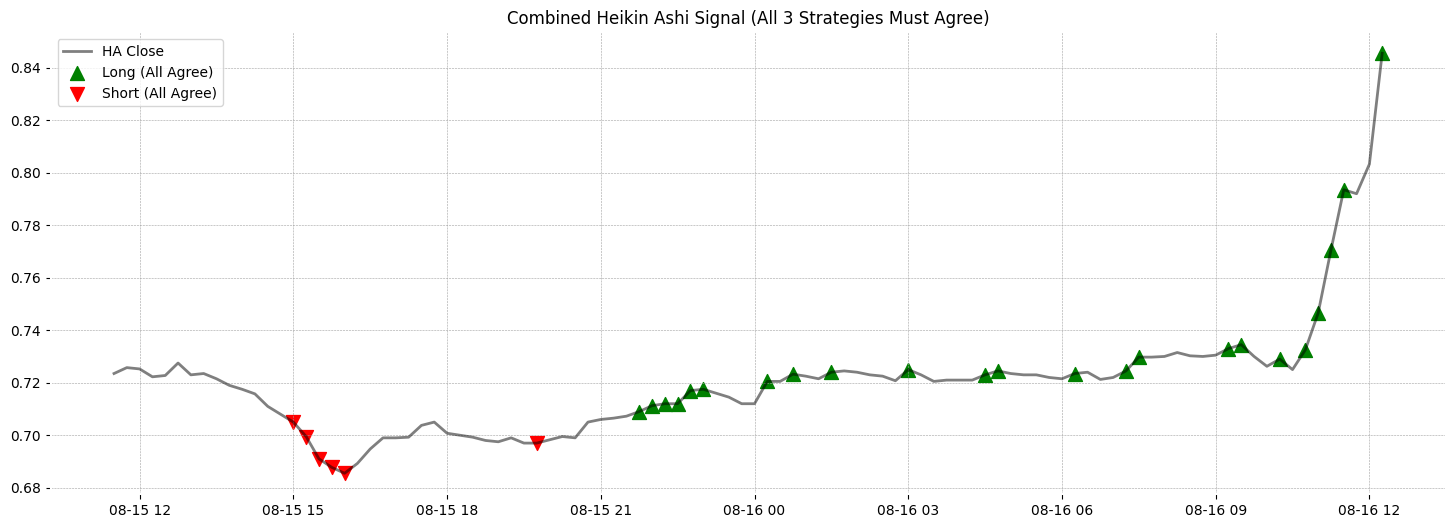

In [21]:
# Restore: emit long when all three agree on long, short when all three agree on short
ha_df['HA_Combined_Signal'] = 0
long_mask = (ha_df['HA_MA_Signal'] == 1) & (ha_df['HA_Wickless_Signal'] == 1) & (ha_df['HA_RSI_Signal'] == 1)
short_mask = (ha_df['HA_MA_Signal'] == -1) & (ha_df['HA_Wickless_Signal'] == -1) & (ha_df['HA_RSI_Signal'] == -1)
ha_df.loc[long_mask, 'HA_Combined_Signal'] = 1
ha_df.loc[short_mask, 'HA_Combined_Signal'] = -1

# Plot the combined signal
plt.figure(figsize=(18,6))
plt.plot(ha_df.index, ha_df['close'], label='HA Close', color='black', alpha=0.5)
plt.scatter(ha_df.index[ha_df['HA_Combined_Signal'] == 1], ha_df['close'][ha_df['HA_Combined_Signal'] == 1], marker='^', color='green', label='Long (All Agree)', s=100)
plt.scatter(ha_df.index[ha_df['HA_Combined_Signal'] == -1], ha_df['close'][ha_df['HA_Combined_Signal'] == -1], marker='v', color='red', label='Short (All Agree)', s=100)
plt.title('Combined Heikin Ashi Signal (All 3 Strategies Must Agree)')
plt.legend()
plt.show()